In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp4_hybrid_lie_residual"
LATENT_DIM = 16   # must match Task-1 VAE

EPOCHS_ORACLE = 15
EPOCHS_T      = 60
BATCH_SIZE    = 256
LR_T          = 3e-4

# Orbit steps used in L_orbit (1..ORBIT_K steps × 30° each)
ORBIT_K = 6   # trains on 30°, 60°, 90°, 120°, 150°, 180° simultaneously

# Loss weights
W_SUP     = 1.0    # primary supervised
W_COMPOSE = 0.4    # angle composition (group homomorphism)
W_INV     = 0.3    # invertibility
W_ORBIT   = 0.3    # full orbit
W_AREG    = 0.02   # Frobenius norm of Lie algebra A
W_DREG    = 0.1    # determinant = 1 constraint


TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp4_hybrid_lie_residual


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    imgs = imgs.clamp(0., 1.)
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles

train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))

ANGLES  = sorted(train_angs.unique().tolist())
DIGITS  = sorted(train_lbls.unique().tolist())
DIG_MAP = {d: i for i, d in enumerate(DIGITS)}
TARGET  = [a for a in ANGLES if a != 0]

pin = device.type == "cuda"
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs, test_lbls, test_angs),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin)
print(f"train: {len(train_imgs):,}   test: {len(test_imgs):,}")

  loading rotated_mnist_train.h5 ... done  (478 MB, 2.2s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.4s)
train: 152,400   test: 26,004


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))

class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)

class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64),  nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,  32, 4, 2, 1),                  nn.GroupNorm(8, 32),  nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,   1, 4, 2, 3),                  nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))

class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld)
        self.decoder = T1Decoder(ld)
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5 * lv).exp() if self.training else mu
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu, lv)), mu, lv

vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ckpt = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ckpt["model"])
    print(f"Task-1 VAE loaded (epoch {ckpt['epoch']})")
else:
    print("⚠ Task-1 checkpoint not found — using random VAE weights (replace TASK1_CKPT)")

vae.eval()
for p in vae.parameters():
    p.requires_grad = False

Task-1 VAE loaded (epoch 47)


In [5]:
class Oracle(nn.Module):
    def __init__(self, ld, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 32),  nn.ReLU(),
            nn.Linear(32, nc),
        )
    def forward(self, z): return self.net(z)

psi = Oracle(LATENT_DIM, len(DIGITS)).to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=1e-3)
print(f"\nTraining Oracle for {EPOCHS_ORACLE} epochs …")

for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train(); correct = total = 0
    for imgs, lbls, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        cls  = torch.tensor([DIG_MAP[l.item()] for l in lbls], device=device)
        with torch.no_grad():
            mu, _ = vae.encode(imgs)
        opt_psi.zero_grad()
        logits = psi(mu)
        F.cross_entropy(logits, cls).backward()
        opt_psi.step()
        correct += (logits.detach().argmax(1) == cls).sum().item()
        total   += imgs.size(0)
    if ep % 5 == 0 or ep == 1:
        print(f"  Oracle ep {ep:2d}/{EPOCHS_ORACLE}  acc={correct/total:.4f}")

psi.eval()
for p in psi.parameters():
    p.requires_grad = False
print("Oracle frozen.")


Training Oracle for 15 epochs …
  Oracle ep  1/15  acc=0.9849
  Oracle ep  5/15  acc=0.9886
  Oracle ep 10/15  acc=0.9888
  Oracle ep 15/15  acc=0.9892
Oracle frozen.


In [6]:
class LieAlgebraModule(nn.Module):
    """
    Learns a single generator A ∈ so(d) (d×d skew-symmetric matrix)
    of the one-parameter Lie group acting on latent space.

    The rotation matrix at angle θ (radians) is:
        R(θ) = expm(θ · A)

    Skew-symmetry is enforced by construction:
        A = L − L^T  where L = lower triangular part of learnable parameter.

    Group-theoretic properties guaranteed by construction:
        • Invertibility:  R(θ)^{-1} = R(−θ) = expm(−θ A)
        • Composition:    R(α) R(β) = R(α+β)  (by Lie group property)
        • det(R(θ)) = 1  (since tr(A) = 0 for skew-symmetric A)
    """
    def __init__(self, ld: int):
        super().__init__()
        self.ld = ld
        self.L_lower = nn.Parameter(torch.zeros(ld, ld))
        nn.init.uniform_(self.L_lower, -0.02, 0.02)

    def get_A(self) -> torch.Tensor:
        """Construct skew-symmetric A from lower-triangular parameter."""
        L = torch.tril(self.L_lower, diagonal=-1)
        return L - L.T   # skew-symmetric by construction

    def R(self, theta_rad: float) -> torch.Tensor:
        """Rotation matrix R(θ) = expm(θ·A) ∈ GL(d)."""
        return torch.linalg.matrix_exp(theta_rad * self.get_A())

    def forward(self, z: torch.Tensor, theta_rad: float) -> torch.Tensor:
        """Apply linear rotation: R(θ) · z."""
        return z @ self.R(theta_rad).T   # right-multiply for batch

    def inverse(self, z: torch.Tensor, theta_rad: float) -> torch.Tensor:
        """Exact inverse: R(-θ) · z."""
        return z @ self.R(-theta_rad).T

    def reg_loss(self) -> torch.Tensor:
        """Frobenius norm regularization: keep A bounded."""
        A = self.get_A()
        return (A * A).mean()

    def det_loss(self, theta_rad: float) -> torch.Tensor:
        """Penalize |det(R(θ)) - 1|: enforce volume preservation."""
        return (torch.linalg.det(self.R(theta_rad)) - 1.).abs()

In [7]:
class ResidualCorrection(nn.Module):
    """
    Small angle-conditioned MLP that corrects the linear Lie rotation.

    Input:  [z;  sin(θ), cos(θ), sin(2θ), cos(2θ)]
    Output: δz  (displacement, added to the Lie rotation result)

    Design principle: δ should be small (L2-regularized), acting as a
    perturbative correction to the dominant linear group action.
    """
    ANGLE_FEATS = 4

    def __init__(self, ld: int, hidden: int = 128):
        super().__init__()
        inp = ld + self.ANGLE_FEATS
        self.net = nn.Sequential(
            nn.Linear(inp, hidden),     nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, ld),
        )
        # Very small init — residual should start near zero
        nn.init.uniform_(self.net[-1].weight, -0.005, 0.005)
        nn.init.zeros_(self.net[-1].bias)

    @staticmethod
    def angle_features(theta_rad: float, B: int, dev) -> torch.Tensor:
        th = torch.tensor(theta_rad, dtype=torch.float32)
        feats = torch.stack([th.sin(), th.cos(), (2*th).sin(), (2*th).cos()])
        return feats.unsqueeze(0).expand(B, -1).to(dev)

    def forward(self, z: torch.Tensor, theta_rad: float) -> torch.Tensor:
        ang = self.angle_features(theta_rad, z.size(0), z.device)
        return self.net(torch.cat([z, ang], dim=1))

In [8]:
class HybridLieTransform(nn.Module):
    """
    Full hybrid transform:
        T(z, θ) = LieAlgebraModule(z, θ) + ResidualCorrection(z, θ)

    The decomposition ensures:
      - Global structure (group composition, invertibility) is captured by Lie part.
      - Local latent-space nonlinearities are handled by the residual.
    """
    def __init__(self, ld: int):
        super().__init__()
        self.lie = LieAlgebraModule(ld)
        self.res = ResidualCorrection(ld)

    def forward(self, z: torch.Tensor, theta_rad: float) -> torch.Tensor:
        return self.lie(z, theta_rad) + self.res(z, theta_rad)

    def inverse_approx(self, z: torch.Tensor, theta_rad: float,
                        n_iters: int = 4) -> torch.Tensor:
        """
        Approximate inverse using Newton-like iteration:
            T^{-1}(y) ≈ Lie^{-1}(y − δ(T^{-1}(y), θ))
        Initialize with Lie^{-1}(y), then iterate.
        """
        z_k = self.lie.inverse(z, theta_rad)
        for _ in range(n_iters):
            delta = self.res(z_k, theta_rad)
            z_k   = self.lie.inverse(z - delta, theta_rad)
        return z_k

T_net = HybridLieTransform(LATENT_DIM).to(device)
lie_params = sum(p.numel() for p in T_net.lie.parameters())
res_params = sum(p.numel() for p in T_net.res.parameters())
print(f"\nHybrid Transform: Lie {lie_params:,} + Residual {res_params:,} = {lie_params+res_params:,} total params")


Hybrid Transform: Lie 256 + Residual 21,776 = 22,032 total params


In [9]:
print("\n── Phase 2: Hybrid Lie Algebra + Nonlinear Residual ───────────────")

theta30  = float(np.radians(30.))

opt_T   = torch.optim.AdamW(T_net.parameters(), lr=LR_T, weight_decay=1e-5)
sched_T = torch.optim.lr_scheduler.CosineAnnealingLR(opt_T, T_max=EPOCHS_T)

history = {k: [] for k in ["sup", "compose", "inv", "orbit", "areg", "dreg",
                             "total", "val_90_lat", "val_90_pix"]}
best_val = float("inf")

for ep in range(1, EPOCHS_T + 1):
    T_net.train()
    acc = {k: 0.0 for k in ["sup", "compose", "inv", "orbit", "areg", "dreg"]}
    n_batches = 0

    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)

        img_30 = tvrotate(imgs, 30., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

        with torch.no_grad():
            z0,   _ = vae.encode(imgs)
            z_30, _ = vae.encode(img_30)

        opt_T.zero_grad(set_to_none=True)

        # ── L_sup: T(z, 30°) ≈ z_{30°} ────────────────────────────────────
        z_hat = T_net(z0, theta30)
        l_sup = F.mse_loss(z_hat, z_30)

        # ── L_compose: T(T(z, α), β) ≈ T(z, α+β) ──────────────────────────
        # Use α=30°, β=30° → T(T(z,30),30) ≈ T(z,60)
        theta60 = float(np.radians(60.))
        img_60  = tvrotate(imgs, 60., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        with torch.no_grad():
            z_60, _ = vae.encode(img_60)
        z_comp   = T_net(z_hat.detach(), theta30)
        z_direct = T_net(z0, theta60)
        l_compose = F.mse_loss(z_comp, z_direct) + F.mse_loss(z_direct, z_60)

        # ── L_inv: T(T(z, 30°), -30°) ≈ z ─────────────────────────────────
        z_inv = T_net.inverse_approx(z_hat.detach(), theta30, n_iters=3)
        l_inv = F.mse_loss(z_inv, z0)

        # ── L_orbit: multi-step orbit consistency ───────────────────────────
        l_orbit = torch.tensor(0., device=device)
        z_roll  = z0.clone()
        for k in range(1, ORBIT_K + 1):
            th_k   = float(np.radians(k * 30))
            img_k  = tvrotate(imgs, float(k * 30),
                               interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
            with torch.no_grad():
                z_k_gt, _ = vae.encode(img_k)
            # direct Lie prediction for orbit (clean supervision signal)
            z_k_pred = T_net(z0, th_k)
            l_orbit  = l_orbit + F.mse_loss(z_k_pred, z_k_gt)
        l_orbit = l_orbit / ORBIT_K

        # ── L_areg: Frobenius norm of A ─────────────────────────────────────
        l_areg = T_net.lie.reg_loss()

        # ── L_dreg: |det(R(90°)) - 1| ───────────────────────────────────────
        theta90 = float(np.radians(90.))
        l_dreg  = T_net.lie.det_loss(theta90)

        loss = (W_SUP     * l_sup     +
                W_COMPOSE * l_compose +
                W_INV     * l_inv     +
                W_ORBIT   * l_orbit   +
                W_AREG    * l_areg    +
                W_DREG    * l_dreg)

        loss.backward()
        nn.utils.clip_grad_norm_(T_net.parameters(), 1.0)
        opt_T.step()

        acc["sup"]     += l_sup.item()
        acc["compose"] += l_compose.item()
        acc["inv"]     += l_inv.item()
        acc["orbit"]   += l_orbit.item()
        acc["areg"]    += l_areg.item()
        acc["dreg"]    += l_dreg.item()
        n_batches += 1

    sched_T.step()
    for k in acc: acc[k] /= n_batches
    total = (W_SUP * acc["sup"] + W_COMPOSE * acc["compose"] +
             W_INV * acc["inv"] + W_ORBIT * acc["orbit"] +
             W_AREG * acc["areg"] + W_DREG * acc["dreg"])

    # validation: T(z, 90°) vs E(rotate(x, 90°))  [latent + pixel]
    T_net.eval()
    with torch.no_grad():
        pool   = (test_angs == 0).nonzero(as_tuple=True)[0][:300]
        x_val  = test_imgs[pool].to(device)
        z_val, _ = vae.encode(x_val)
        x90_val  = tvrotate(x_val, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt90, _ = vae.encode(x90_val)
        z_pred90  = T_net(z_val, float(np.radians(90.)))
        val_90_lat = F.mse_loss(z_pred90, z_gt90).item()
        val_90_pix = F.mse_loss(vae.decode(z_pred90).clamp(0.,1.), x90_val).item()
        val_score  = val_90_lat + 0.5 * val_90_pix
    T_net.train()

    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_90_lat"].append(val_90_lat)
    history["val_90_pix"].append(val_90_pix)

    if val_score < best_val:
        best_val = val_score
        torch.save({"T": T_net.state_dict(), "psi": psi.state_dict(), "epoch": ep,
                    "val_score": best_val}, os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
    else:
        tag = ""

    if ep % 5 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_T}  sup={acc['sup']:.5f}  "
              f"compose={acc['compose']:.5f}  inv={acc['inv']:.5f}  "
              f"orbit={acc['orbit']:.5f}  "
              f"val_90_lat={val_90_lat:.5f}  val_90_pix={val_90_pix:.5f}{tag}")

ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
T_net.load_state_dict(ck["T"]); psi.load_state_dict(ck["psi"])
T_net.eval()
print(f"Best model loaded (epoch {ck['epoch']}, val_score={ck['val_score']:.5f})")


── Phase 2: Hybrid Lie Algebra + Nonlinear Residual ───────────────
  ep   1/60  sup=0.00354  compose=0.00813  inv=0.00120  orbit=0.00837  val_90_lat=0.00429  val_90_pix=0.05434  ★
  ep   2/60  sup=0.00168  compose=0.00233  inv=0.00071  orbit=0.00308  val_90_lat=0.00259  val_90_pix=0.04652  ★
  ep   3/60  sup=0.00155  compose=0.00215  inv=0.00058  orbit=0.00257  val_90_lat=0.00226  val_90_pix=0.04431  ★
  ep   4/60  sup=0.00144  compose=0.00194  inv=0.00053  orbit=0.00227  val_90_lat=0.00196  val_90_pix=0.04231  ★
  ep   5/60  sup=0.00134  compose=0.00177  inv=0.00048  orbit=0.00206  val_90_lat=0.00185  val_90_pix=0.04279
  ep   7/60  sup=0.00127  compose=0.00171  inv=0.00045  orbit=0.00189  val_90_lat=0.00175  val_90_pix=0.04140  ★
  ep   8/60  sup=0.00123  compose=0.00165  inv=0.00044  orbit=0.00182  val_90_lat=0.00170  val_90_pix=0.03797  ★
  ep  10/60  sup=0.00118  compose=0.00158  inv=0.00045  orbit=0.00174  val_90_lat=0.00157  val_90_pix=0.03876
  ep  12/60  sup=0.00113  compose

In [10]:
@torch.no_grad()
def evaluate():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:500]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    # M1 — direct angle prediction for each target angle
    m1_lat, m1_pix = {}, {}
    for theta in TARGET:
        th_rad = float(np.radians(theta))
        xr = tvrotate(x0, float(theta), interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt, _ = vae.encode(xr)
        z_pred   = T_net(z0, th_rad)
        m1_lat[theta] = F.mse_loss(z_pred, z_gt).item()
        m1_pix[theta] = F.mse_loss(vae.decode(z_pred).clamp(0.,1.), xr).item()
    m1_lat_mean = float(np.mean(list(m1_lat.values())))
    m1_pix_mean = float(np.mean(list(m1_pix.values())))

    # M2 — oracle drift at 360°
    z360 = T_net(z0, float(np.radians(360.)))
    p0   = torch.softmax(psi(z0), dim=1)
    m2   = F.mse_loss(torch.softmax(psi(z360), dim=1), p0).item()

    # M3 — step norm at 30°
    dz30 = T_net(z0, theta30) - z0
    m3m  = dz30.norm(dim=1).mean().item()
    m3s  = dz30.norm(dim=1).std().item()

    # M4 — composition error: T(T(z,30),30) vs T(z,60)
    z30    = T_net(z0, theta30)
    z30_30 = T_net(z30, theta30)
    z60    = T_net(z0, float(np.radians(60.)))
    m4     = F.mse_loss(z30_30, z60).item()

    # Group-theoretic diagnostics (Lie algebra module only)
    A = T_net.lie.get_A().detach().cpu().numpy()
    skew_err = float(np.linalg.norm(A + A.T))   # should be ~0

    R90 = T_net.lie.R(float(np.radians(90.))).detach()
    det_err  = float(abs(torch.linalg.det(R90).item() - 1.))

    R30  = T_net.lie.R(theta30).detach()
    R60  = T_net.lie.R(float(np.radians(60.))).detach()
    comp_err = float((torch.mm(R30, R30) - R60).norm().item())

    R30_inv = T_net.lie.R(-theta30).detach()
    inv_err = float((torch.mm(R30, R30_inv) - torch.eye(LATENT_DIM, device=device)).norm().item())

    return (m1_lat, m1_pix, m1_lat_mean, m1_pix_mean,
            m2, m3m, m3s, m4,
            skew_err, det_err, comp_err, inv_err)

(m1_lat, m1_pix, m1_lat_mean, m1_pix_mean,
 m2, m3m, m3s, m4,
 skew_err, det_err, comp_err, inv_err) = evaluate()

print("\n══════════════════ FINAL METRICS ══════════════════")
print(f"M1 Latent MSE (mean, direct) : {m1_lat_mean:.5f}")
print(f"M1 Pixel  MSE (mean, direct) : {m1_pix_mean:.5f}")
for theta in TARGET:
    print(f"     θ={theta:4d}°  lat={m1_lat[theta]:.5f}  pix={m1_pix[theta]:.5f}")
print(f"M2 Oracle drift (360°)       : {m2:.5f}")
print(f"M3 Step norm mean ± std      : {m3m:.4f} ± {m3s:.4f}")
print(f"M4 Composition error         : {m4:.5f}")
print("── Lie Algebra Diagnostics ──────────────────────────")
print(f"||A + A^T||_F  (skew err)    : {skew_err:.2e}   [→ 0 is perfect]")
print(f"|det(R(90°)) - 1|            : {det_err:.2e}    [→ 0 is perfect]")
print(f"||R^2 - R(60°)||_F           : {comp_err:.2e}  [→ 0 is perfect]")
print(f"||R·R^{-1} - I||_F          : {inv_err:.2e}   [→ 0 is perfect]")
print("═══════════════════════════════════════════════════")

np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP4_HYBRID_LIE_RESIDUAL",
    "m1_lat_per_angle": m1_lat,
    "m1_pix_per_angle": m1_pix,
    "m1_lat_mean": m1_lat_mean,
    "m1_pix_mean": m1_pix_mean,
    "m2_oracle_drift": m2,
    "m3_norm_mean": m3m,
    "m3_norm_std": m3s,
    "m4_compose_error": m4,
    "lie_diagnostics": {
        "skew_error": skew_err,
        "det_error":  det_err,
        "compose_error": comp_err,
        "inverse_error": inv_err,
    },
    "history": history,
}, allow_pickle=True)


══════════════════ FINAL METRICS ══════════════════
M1 Latent MSE (mean, direct) : 0.03682
M1 Pixel  MSE (mean, direct) : 0.05961
     θ=  30°  lat=0.00107  pix=0.02939
     θ=  60°  lat=0.00080  pix=0.02987
     θ=  90°  lat=0.00129  pix=0.03705
     θ= 120°  lat=0.00135  pix=0.02984
     θ= 150°  lat=0.00101  pix=0.02969
     θ= 180°  lat=0.00113  pix=0.03765
     θ= 210°  lat=0.03180  pix=0.06846
     θ= 240°  lat=0.03539  pix=0.08264
     θ= 270°  lat=0.07412  pix=0.10408
     θ= 300°  lat=0.14313  pix=0.11351
     θ= 330°  lat=0.11395  pix=0.09348
M2 Oracle drift (360°)       : 0.42335
M3 Step norm mean ± std      : 0.8441 ± 0.2922
M4 Composition error         : 0.00014
── Lie Algebra Diagnostics ──────────────────────────
||A + A^T||_F  (skew err)    : 0.00e+00   [→ 0 is perfect]
|det(R(90°)) - 1|            : 1.19e-07    [→ 0 is perfect]
||R^2 - R(60°)||_F           : 4.18e-07  [→ 0 is perfect]
||R·R^-1 - I||_F          : 1.90e-07   [→ 0 is perfect]
════════════════════════════

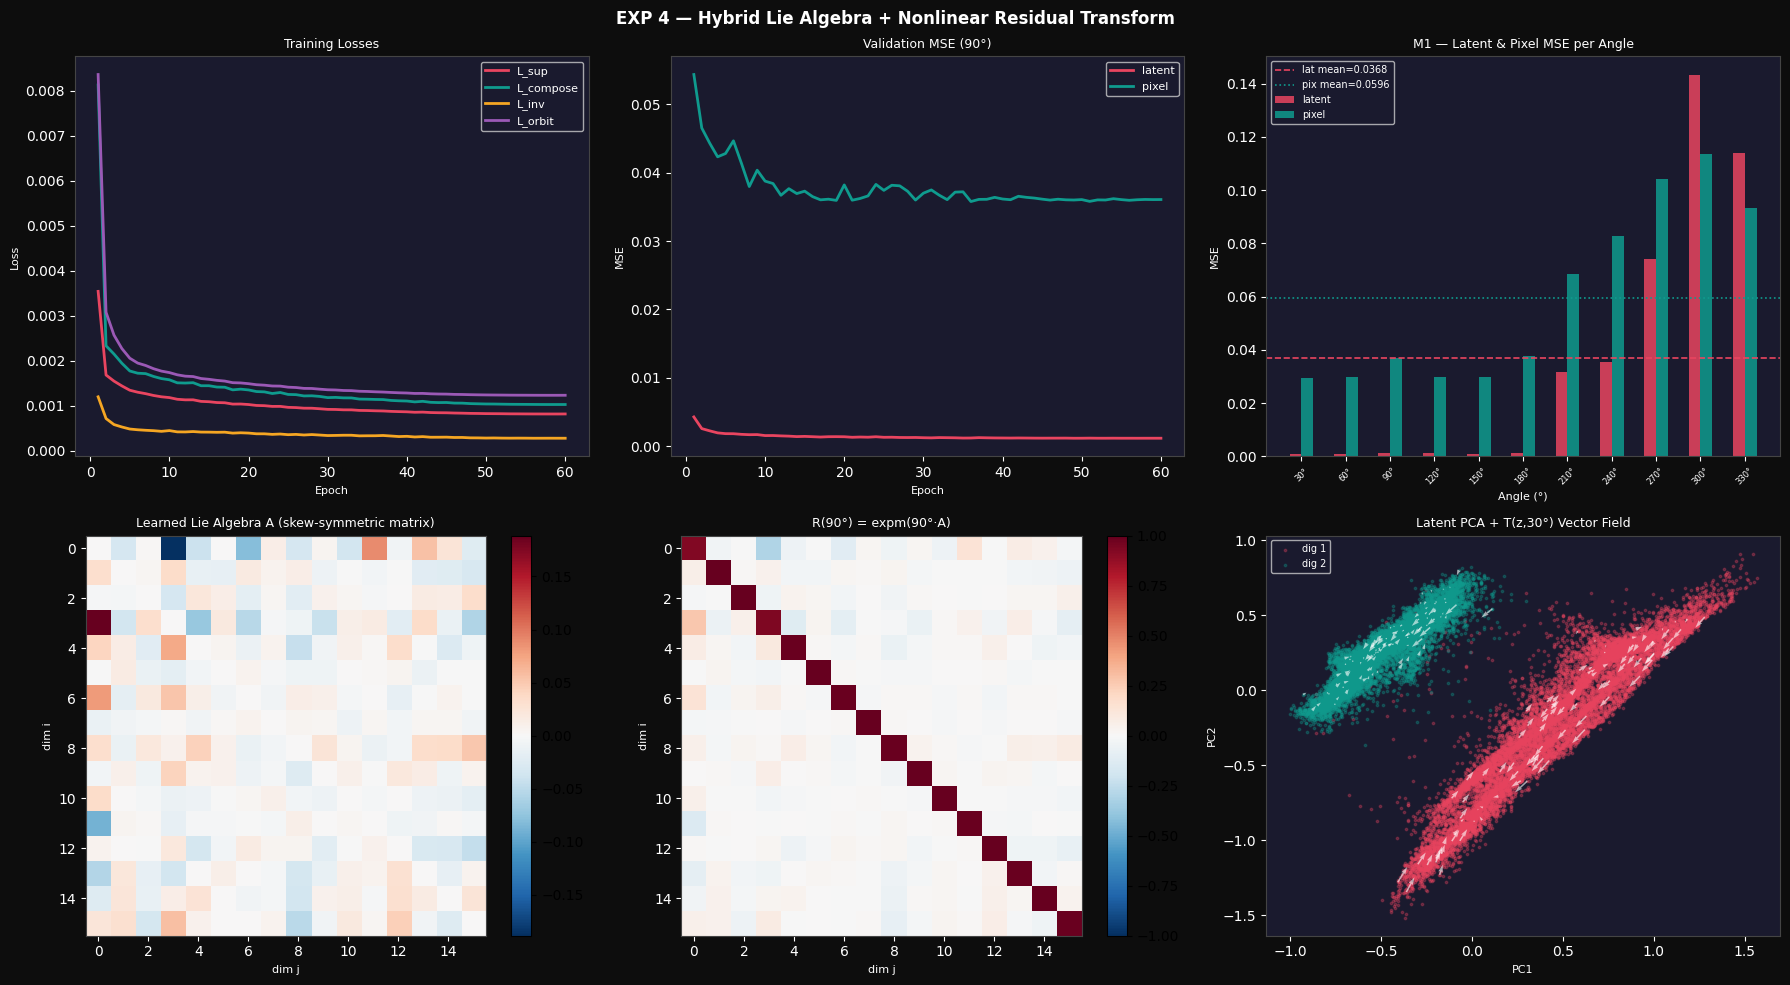

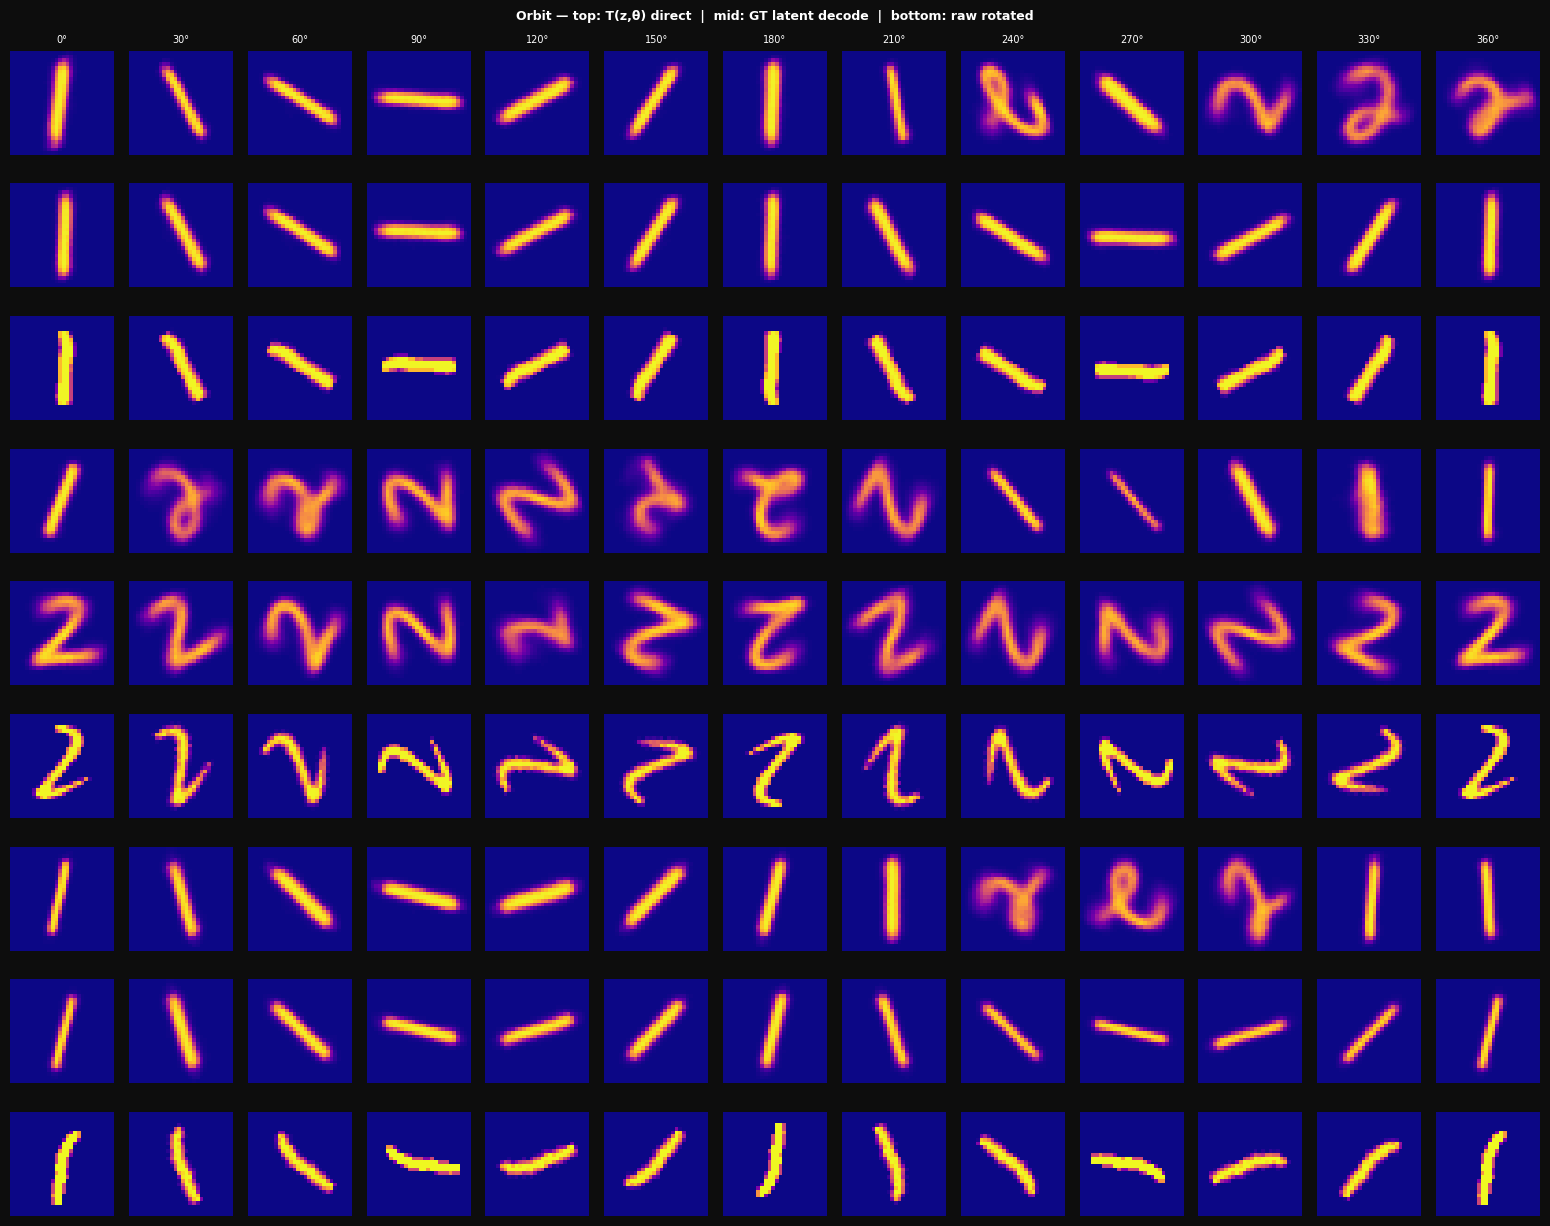


✅ EXP 4 (Hybrid Lie + Residual) complete
   M1_lat=0.03682  M1_pix=0.05961  M2=0.42335
   Lie diagnostics — skew=0.00e+00  det=1.19e-07  compose=4.18e-07


In [11]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"

def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK)
fig.suptitle("EXP 4 — Hybrid Lie Algebra + Nonlinear Residual Transform",
             color="white", fontsize=12, fontweight="bold")

ep_ax = range(1, EPOCHS_T + 1)
_ax(axes[0,0], "Training Losses", "Epoch", "Loss")
axes[0,0].plot(ep_ax, history["sup"],     color="#e94560", lw=2, label="L_sup")
axes[0,0].plot(ep_ax, history["compose"], color="#0f9b8e", lw=2, label="L_compose")
axes[0,0].plot(ep_ax, history["inv"],     color="#f5a623", lw=2, label="L_inv")
axes[0,0].plot(ep_ax, history["orbit"],   color="#9b59b6", lw=2, label="L_orbit")
axes[0,0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)

_ax(axes[0,1], "Validation MSE (90°)", "Epoch", "MSE")
axes[0,1].plot(ep_ax, history["val_90_lat"], color="#e94560", lw=2, label="latent")
axes[0,1].plot(ep_ax, history["val_90_pix"], color="#0f9b8e", lw=2, label="pixel")
axes[0,1].legend(facecolor=PANEL, labelcolor="white", fontsize=8)

_ax(axes[0,2], "M1 — Latent & Pixel MSE per Angle", "Angle (°)", "MSE")
thetas = list(m1_lat.keys())
w = 8
axes[0,2].bar([t - w//2 for t in thetas], list(m1_lat.values()),
              width=w, color="#e94560", alpha=0.85, label="latent")
axes[0,2].bar([t + w//2 for t in thetas], list(m1_pix.values()),
              width=w, color="#0f9b8e", alpha=0.85, label="pixel")
axes[0,2].axhline(m1_lat_mean, color="#e94560", ls="--", lw=1.2, label=f"lat mean={m1_lat_mean:.4f}")
axes[0,2].axhline(m1_pix_mean, color="#0f9b8e", ls=":",  lw=1.2, label=f"pix mean={m1_pix_mean:.4f}")
axes[0,2].set_xticks(thetas)
axes[0,2].set_xticklabels([f"{t}°" for t in thetas], color="white", fontsize=6, rotation=45)
axes[0,2].legend(facecolor=PANEL, labelcolor="white", fontsize=7)

# Lie algebra heatmap |A|
with torch.no_grad():
    A_np = T_net.lie.get_A().cpu().numpy()
_ax(axes[1,0], "Learned Lie Algebra A (skew-symmetric matrix)", "dim j", "dim i")
im = axes[1,0].imshow(A_np, cmap="RdBu_r", vmin=-abs(A_np).max(), vmax=abs(A_np).max())
plt.colorbar(im, ax=axes[1,0])

# Rotation matrix heatmap at 90°
with torch.no_grad():
    R90_np = T_net.lie.R(float(np.radians(90.))).cpu().numpy()
_ax(axes[1,1], "R(90°) = expm(90°·A)", "dim j", "dim i")
im2 = axes[1,1].imshow(R90_np, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im2, ax=axes[1,1])

# Latent PCA + T vector field
with torch.no_grad():
    Zs, Ls = [], []
    for imgs, lbls, _ in test_loader:
        mu, _ = vae.encode(imgs.to(device))
        Zs.append(mu.cpu().numpy()); Ls.append(lbls.numpy())
Z_all = np.concatenate(Zs); L_all = np.concatenate(Ls)
pca   = PCA(n_components=2).fit(Z_all)
Z2    = pca.transform(Z_all)

_ax(axes[1,2], "Latent PCA + T(z,30°) Vector Field", "PC1", "PC2")
COLORS = ["#e94560","#0f9b8e","#5bc0de","#f0ad4e","#9b59b6",
          "#2ecc71","#ff7f7f","#7f8c8d","#1abc9c","#3498db"]
for i, d in enumerate(DIGITS):
    mask = (L_all == d)
    axes[1,2].scatter(Z2[mask, 0], Z2[mask, 1], s=3, alpha=0.3,
                      color=COLORS[i % len(COLORS)], label=f"dig {d}")

idx  = np.random.choice(len(Z_all), min(200, len(Z_all)), replace=False)
Z_g  = torch.from_numpy(Z_all[idx]).to(device)
with torch.no_grad():
    T30_vec = (T_net(Z_g, theta30) - Z_g).cpu().numpy() @ pca.components_.T
axes[1,2].quiver(Z2[idx, 0], Z2[idx, 1], T30_vec[:, 0], T30_vec[:, 1],
                 color="white", alpha=0.6, scale=30, width=0.003)
axes[1,2].legend(facecolor=PANEL, labelcolor="white", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

# ── orbit ─────────────────────────────────────────────────────────────────────
@torch.no_grad()
def plot_orbit(n_samples: int = 3):
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:n_samples]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    angles_show = list(range(0, 360 + 30, 30))   # 0° … 360°
    n_show = len(angles_show)

    fig, axes = plt.subplots(n_samples * 3, n_show, figsize=(n_show * 1.2, n_samples * 4.2), facecolor=DARK)
    fig.suptitle("Orbit — top: T(z,θ) direct  |  mid: GT latent decode  |  bottom: raw rotated",
                 color="white", fontsize=9, fontweight="bold")

    for row in range(n_samples):
        for col, angle in enumerate(angles_show):
            th_rad = float(np.radians(angle))
            xr = x0[row:row+1] if angle == 0 else tvrotate(
                x0[row:row+1], float(angle % 360),
                interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

            z_pred = T_net(z0[row:row+1], th_rad)
            pred   = vae.decode(z_pred).clamp(0.,1.).cpu().squeeze().numpy()
            axes[row*3,   col].imshow(pred, cmap="plasma", vmin=0, vmax=1)
            axes[row*3,   col].axis("off")

            z_gt, _ = vae.encode(xr)
            gt_dec  = vae.decode(z_gt).clamp(0.,1.).cpu().squeeze().numpy()
            axes[row*3+1, col].imshow(gt_dec, cmap="plasma", vmin=0, vmax=1)
            axes[row*3+1, col].axis("off")

            axes[row*3+2, col].imshow(xr.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
            axes[row*3+2, col].axis("off")

            if row == 0:
                axes[0, col].set_title(f"{angle}°", color="white", fontsize=7)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbit.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()

plot_orbit()

print(f"\n✅ EXP 4 (Hybrid Lie + Residual) complete")
print(f"   M1_lat={m1_lat_mean:.5f}  M1_pix={m1_pix_mean:.5f}  M2={m2:.5f}")
print(f"   Lie diagnostics — skew={skew_err:.2e}  det={det_err:.2e}  compose={comp_err:.2e}")